In [15]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score

In [16]:
# Upload dataset
from google.colab import files
uploaded = files.upload()

Saving student_performance_dataset.csv to student_performance_dataset (1).csv


In [17]:
# Dataframe
df = pd.read_csv('student_performance_dataset.csv')

# Display the first 5 rows to verify structure
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (708, 10)


,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


In [18]:
# Check for missing values
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 Student_ID                    0
Gender                        0
Study_Hours_per_Week          0
Attendance_Rate               0
Past_Exam_Scores              0
Parental_Education_Level      0
Internet_Access_at_Home       0
Extracurricular_Activities    0
Final_Exam_Score              0
Pass_Fail                     0
dtype: int64


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  708 non-null    object 
 1   Gender                      708 non-null    object 
 2   Study_Hours_per_Week        708 non-null    int64  
 3   Attendance_Rate             708 non-null    float64
 4   Past_Exam_Scores            708 non-null    int64  
 5   Parental_Education_Level    708 non-null    object 
 6   Internet_Access_at_Home     708 non-null    object 
 7   Extracurricular_Activities  708 non-null    object 
 8   Final_Exam_Score            708 non-null    int64  
 9   Pass_Fail                   708 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 55.4+ KB


In [20]:
# Encode categorical columns
# Automatically detect and encode object columns
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("Data types after encoding:")
print(df.dtypes)

Data types after encoding:
Student_ID                      int64
Gender                          int64
Study_Hours_per_Week            int64
Attendance_Rate               float64
Past_Exam_Scores                int64
Parental_Education_Level        int64
Internet_Access_at_Home         int64
Extracurricular_Activities      int64
Final_Exam_Score                int64
Pass_Fail                       int64
dtype: object


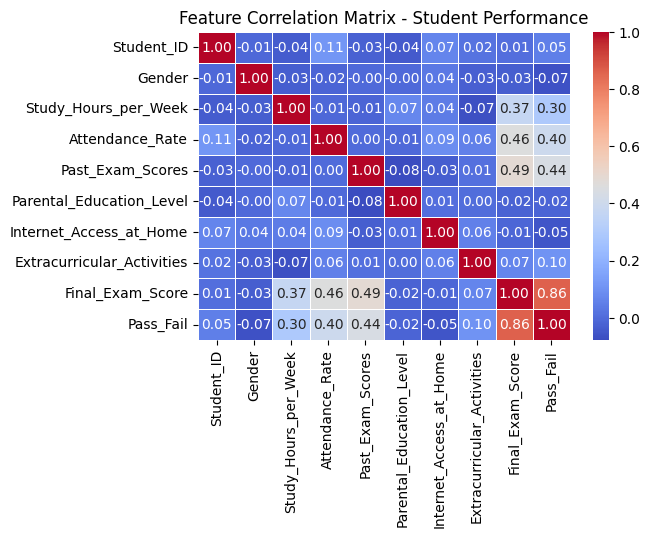

In [21]:
# Exploratory Data Analysis (EDA) Plot
# Correlation heatmap to see feature relationships
plt.figure(figsize=(6, 4))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Feature Correlation Matrix - Student Performance")
plt.show()

In [22]:
# - - - Classification Model - - -
# Drop irrelevant columns from X for classification
columns_to_drop = ['Pass_Fail', 'Final_Exam_Score', 'Student_ID']

X_class = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
y_class = df['Pass_Fail']

# Split data: 80% training, 20% testing
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

# Train a Random Forest Classifier
clf_model = RandomForestClassifier(random_state=42)
clf_model.fit(X_train_c, y_train_c)

# Evaluate Classification Model
y_pred_clf = clf_model.predict(X_test_c)
print("--- CLASSIFICATION MODEL RESULTS ---")
print(f"Accuracy Score: {accuracy_score(y_test_c, y_pred_clf):.4f}")
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_clf))

# Check feature importances to verify the model using behavioral data
importances = pd.Series(clf_model.feature_importances_, index=X_class.columns)
print("\nFeature Importances:\n", importances.sort_values(ascending=False))

--- CLASSIFICATION MODEL RESULTS ---
Accuracy Score: 0.9155

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.86      0.91        71
           1       0.87      0.97      0.92        71

    accuracy                           0.92       142
   macro avg       0.92      0.92      0.92       142
weighted avg       0.92      0.92      0.92       142


Feature Importances:
 Past_Exam_Scores              0.330851
Attendance_Rate               0.312131
Study_Hours_per_Week          0.216036
Parental_Education_Level      0.065630
Gender                        0.026121
Extracurricular_Activities    0.024815
Internet_Access_at_Home       0.024417
dtype: float64


In [23]:
# - - - Regression model - - -
target_reg = 'Final_Exam_Score'
X_reg = df.drop(columns=[target_reg])
y_reg = df[target_reg]

# Split data
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Train a Linear Regression Model
reg_model = LinearRegression()
reg_model.fit(X_train_r, y_train_r)

# Evaluate Regression Model
y_pred_reg = reg_model.predict(X_test_r)
mse = mean_squared_error(y_test_r, y_pred_reg)
r2 = r2_score(y_test_r, y_pred_reg)

print("--- REGRESSION MODEL RESULTS ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared Score (R2): {r2:.4f}")

--- REGRESSION MODEL RESULTS ---
Mean Squared Error (MSE): 6.7910
R-squared Score (R2): 0.8404


In [24]:
# Comparison of performance of models
from sklearn.metrics import f1_score

comparison_df = pd.DataFrame({
    'Model': ['Random Forest Classifier', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test_c, y_pred_clf),
        accuracy_score(y_test_c, y_pred_lr)
    ],
    'F1-Score (Risk Class)': [
        f1_score(y_test_c, y_pred_clf, pos_label=1),
        f1_score(y_test_c, y_pred_lr, pos_label=1)
    ]
})

print("--- MODEL PERFORMANCE COMPARISON ---")
display(comparison_df)

--- MODEL PERFORMANCE COMPARISON ---


,Model,Accuracy,F1-Score (Risk Class)
0,Random Forest Classifier,0.915493,0.920000
1,Logistic Regression,0.816901,0.824324
